# Interpretable Weakly-Supervised Stuttering Detection

**BSc (Hons) Computer Science — Final Year Project**  
W.W. Kavindu Mihiranga (20221341 / w1956364)  
University of Westminster / Informatics Institute of Technology  
Supervisor: Mr. Rathesan Sivagnanalingam

---

This notebook orchestrates the complete training and evaluation pipeline.
All reusable logic lives in the `src/` package; this notebook serves as a
**thin, readable driver** that calls into those modules.

### Pipeline Phases

| Phase | Description |
|-------|-------------|
| 1 | Environment Setup & Configuration |
| 2 | Dataset Discovery & Exploration |
| 3 | Data Preprocessing & Speaker-Disjoint Splits |
| 4 | Model Architecture Construction |
| 5 | Stage 0 — Rule Pre-training (Synthetic Data) |
| 6 | Stage 1 — MIL Training (Clip-Level Labels) |
| 7 | Pseudo-Label Generation |
| 8 | Stage 2 — Self-Training with Mean Teacher |
| 9 | Evaluation & Metrics |
| 10 | Interpretability Analysis |
| 11 | Ablation Tests |
| 12 | Demo & Summary |

---
## Phase 1 — Environment Setup & Configuration

In [1]:
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

import torch

import os, sys, platform, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Ensure src/ is on the Python path
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.config import Config
from src.utils.helpers import set_seed, Logger

# Initialise
config = Config()

config.DEVICE = torch.device("cpu")

set_seed(config.SEED)
logger = Logger(config.LOG_DIR)

print(f"\nProject Root : {config.PROJECT_ROOT}")
print(f"System       : {platform.system()} {platform.machine()}")
print(f"PyTorch      : {torch.__version__}")
print(f"Device       : {config.DEVICE}")
print(f"Classes      : {config.STUTTER_TYPES}")
print(f"NUM_CLASSES  : {config.NUM_CLASSES}")

logger.log(f"Environment ready. Device={config.DEVICE}")


Project Root : /Users/kavindumihiranga/Documents/Code_Base 3
System       : Darwin arm64
PyTorch      : 2.1.0
Device       : cpu
Classes      : ['interjection', 'prolongation', 'word_repetition']
NUM_CLASSES  : 3
[2026-03-18 10:21:14] [INFO] Environment ready. Device=cpu


---
## Phase 2 — Dataset Discovery & Exploration

  Added 1879 negative (NoStutteredWords) samples (25% of 7519 stutter samples)
Dataset discovery: 9,398 files across 4 classes
  __negative__        :  1879 files
  interjection        :  3171 files
  prolongation        :  2339 files
  word_repetition     :  2009 files

✓ All 3 stutter classes found in dataset


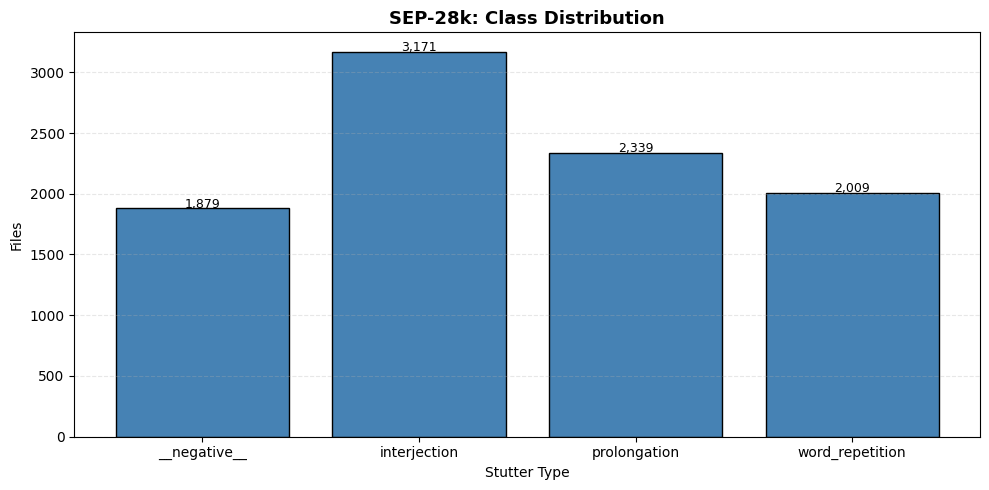

[2026-03-18 10:21:21] [INFO] Dataset: 9398 files, 4 classes


In [2]:
from src.data.splits import discover_dataset
from src.evaluation.visualization import plot_class_distribution

dataset_df = discover_dataset(
    config.DATASET_PATH,
    config.STUTTER_CLASS_MAPPING,
    config.NON_STUTTER_CLASSES,
    include_negatives=getattr(config, 'INCLUDE_NEGATIVES', False),
    negative_ratio=getattr(config, 'NEGATIVE_RATIO', 0.15),
)

# Verify all stutter classes are present
found_classes = set(dataset_df['class'].unique()) - {'__negative__'}
missing = set(config.STUTTER_TYPES) - found_classes
if missing:
    print(f"\n⚠️  CRITICAL: Missing stutter classes: {missing}")
    print("   Check that raw data folders exist and case-insensitive matching works.")
else:
    print(f"\n✓ All {len(config.STUTTER_TYPES)} stutter classes found in dataset")

# Visualise distribution
counts = dataset_df['class'].value_counts().to_dict()
plot_class_distribution(
    counts,
    save_path=os.path.join(config.OUTPUT_DIR, 'visualizations', 'class_distribution.png'),
)

logger.log(f"Dataset: {len(dataset_df)} files, {dataset_df['class'].nunique()} classes")

---
## Phase 3 — Data Preprocessing & Speaker-Disjoint Splits

In [3]:
from src.data.splits import create_speaker_disjoint_splits, save_splits
from src.data.preprocessor import AudioPreprocessor

# Speaker-disjoint splits
dataset_df = create_speaker_disjoint_splits(
    dataset_df,
    train_ratio=config.TRAIN_RATIO,
    val_ratio=config.VAL_RATIO,
    seed=config.SEED,
)

# Save CSVs and label mappings
mappings = save_splits(dataset_df, config.DATA_PROCESSED, config.STUTTER_TYPES)
label2idx = mappings['label2idx']
idx2label = mappings['idx2label']
classes   = mappings['classes']

# Preprocessor
preprocessor = AudioPreprocessor(
    target_sr=config.SAMPLE_RATE,
    clip_duration=config.CLIP_DURATION,
)

# Quick sanity check
test_file = dataset_df.iloc[0]['file_path']
test_audio = preprocessor.load_and_preprocess(test_file)
print(f"Preprocessor test: {os.path.basename(test_file)} -> {len(test_audio)} samples")

config.save()
logger.log("Splits created and saved.")

  train:  6676 clips  (179 speakers)
  val  :  1391 clips  (38 speakers)
  test :  1331 clips  (40 speakers)
  train:  6676 clips (5339 stutter + 1337 negative)
  val  :  1391 clips (1122 stutter + 269 negative)
  test :  1331 clips (1058 stutter + 273 negative)
Splits and label mappings saved to /Users/kavindumihiranga/Documents/Code_Base 3/data/processed
Preprocessor test: HVSA_0_1.wav -> 48000 samples
[2026-03-18 10:21:30] [INFO] Splits created and saved.


---
## Phase 4 — Model Architecture

In [4]:
from transformers import Wav2Vec2Model
from src.models.neurosymbolic import NeuroSymbolicStutterDetector

# Load Wav2Vec2
print("Loading Wav2Vec2 encoder...")
wav2vec2_model = Wav2Vec2Model.from_pretrained(config.WAV2VEC2_MODEL)
print(f"  Params: ~{sum(p.numel() for p in wav2vec2_model.parameters())/1e6:.1f}M")

# Build complete neuro-symbolic model
model = NeuroSymbolicStutterDetector(
    config,
    wav2vec2_model=wav2vec2_model,
    freeze_encoder=True,  # will selectively unfreeze last N layers via config
)
model = model.to(config.DEVICE)

trainable, total = model.count_parameters()
frozen = total - trainable
encoder_trainable = sum(p.numel() for p in model.encoder.parameters() if p.requires_grad)
print(f"\nModel Summary:")
print(f"  Trainable params         : {trainable:,}")
print(f"    of which encoder       : {encoder_trainable:,}")
print(f"  Total params             : {total:,}")
print(f"  Frozen params            : {frozen:,}")
print(f"  Encoder fine-tuning      : last {getattr(config, 'UNFREEZE_ENCODER_LAYERS', 0)} layers")
print(f"  Memory (float32)         : ~{total * 4 / 1024**2:.1f} MB")
print(f"  Temporal hidden dim      : {config.TEMPORAL_HIDDEN_DIM}")
print(f"  MIL pooling              : {config.MIL_POOLING}")
print(f"  Dropout                  : {config.DROPOUT}")
print(f"  Label smoothing          : {getattr(config, 'LABEL_SMOOTHING', 0)}")

# Forward pass smoke test
with torch.no_grad():
    dummy = torch.randn(1, config.MAX_AUDIO_LENGTH).to(config.DEVICE)
    out, det = model(dummy, return_details=True)
    print(f"\nForward pass OK:")
    print(f"  Logits        : {out.shape}")
    print(f"  Rule scores   : {det['rule_scores'].shape}")
    print(f"  Gate weights  : {det['gate_weights'].shape}")

logger.log(f"Model built: {trainable:,} trainable params ({encoder_trainable:,} encoder)")

Loading Wav2Vec2 encoder...


Some weights of Wav2Vec2Model were not initialized from the model checkpoint at facebook/wav2vec2-base-960h and are newly initialized: ['wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'wav2vec2.masked_spec_embed', 'wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original1']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Params: ~94.4M
  Unfroze last 2 of 12 encoder layers

Model Summary:
  Trainable params         : 18,245,540
    of which encoder       : 14,175,744
  Total params             : 98,441,508
  Frozen params            : 80,195,968
  Encoder fine-tuning      : last 2 layers
  Memory (float32)         : ~375.5 MB
  Temporal hidden dim      : 256
  MIL pooling              : mixed
  Dropout                  : 0.3
  Label smoothing          : 0.05

Forward pass OK:
  Logits        : torch.Size([1, 149, 3])
  Rule scores   : torch.Size([1, 149, 3])
  Gate weights  : torch.Size([1, 149, 4])
[2026-03-18 10:21:44] [INFO] Model built: 18,245,540 trainable params (14,175,744 encoder)


---
## Phase 5 — Stage 0: Rule Pre-training on Synthetic Data

In [5]:
from src.training.stage0_rule_pretrain import pretrain_rules

stage0_history = pretrain_rules(
    soft_rules_module=model.soft_rules,
    config=config,
)

# Save pre-trained rule weights
rule_ckpt = os.path.join(config.CHECKPOINT_DIR, 'stage0_rules.pth')
torch.save(model.soft_rules.state_dict(), rule_ckpt)
print(f"Pre-trained rule weights saved: {rule_ckpt}")

logger.log(f"Stage 0 complete. Final loss: {stage0_history['loss'][-1]:.4f}")

Stage 0: Pre-training rules on 5000 synthetic samples for 20 epochs


Stage 0 Ep 1:   0%|          | 0/157 [00:00<?, ?it/s]

  Epoch 1/20  Loss: 0.3615


Stage 0 Ep 2:   0%|          | 0/157 [00:00<?, ?it/s]

  Epoch 2/20  Loss: 0.3062


...

  Epoch 18/20  Loss: 0.1138


Stage 0 Ep 19:   0%|          | 0/157 [00:00<?, ?it/s]

  Epoch 19/20  Loss: 0.1107


Stage 0 Ep 20:   0%|          | 0/157 [00:00<?, ?it/s]

  Epoch 20/20  Loss: 0.1077
  Burst: positive=0.304  negative=0.019  gap=0.285
  Voicing: positive=0.385  negative=0.014  gap=0.370
  Rhythm: positive=0.375  negative=0.033  gap=0.343
Stage 0 complete.
Pre-trained rule weights saved: /Users/kavindumihiranga/Documents/Code_Base 3/models/checkpoints/stage0_rules.pth
[2026-03-18 10:24:24] [INFO] Stage 0 complete. Final loss: 0.1077


---
## Phase 6 — Stage 1: MIL Training

✓ Apple MPS GPU detected
[2026-03-18 10:24:49] [INFO] Environment ready. Device=mps
Train: 6676  Val: 1391  Test: 1331

  Train distribution:
    interjection        :  2303  (34.5%)
    prolongation        :  1634  (24.5%)
    word_repetition     :  1402  (21.0%)
    __negative__        :  1337  (20.0%)

  Val distribution:
    interjection        :   425  (30.6%)
    prolongation        :   396  (28.5%)
    word_repetition     :   301  (21.6%)
    __negative__        :   269  (19.3%)

  Test distribution:
    interjection        :   443  (33.3%)
    prolongation        :   309  (23.2%)
    word_repetition     :   306  (23.0%)
    __negative__        :   273  (20.5%)

✓ Using class-balanced WeightedRandomSampler
Class weights (cap=15.0): {0: 0.77, 1: 1.09, 2: 1.27}
  Encoder params: 14,175,744 (lr=5e-06)

STAGE 1 — MIL TRAINING  (25 epochs)
  Focal gamma: 2.0
  Gate entropy lambda: 0.5 → 0.15 (annealed)
  Warmup steps: 200


Train:   0%|          | 0/417 [00:00<?, ?it/s]

Val:   0%|          | 0/87 [00:00<?, ?it/s]

Ep  1/25  loss=0.2545  val_loss=0.1473  F1=0.238  recall=0.206  gates=[N:0.40 Br:0.21 Vc:0.20 Rh:0.19]  [interjection=0.59  prolongation=0.01  word_repetition=0.02]  ★


Train:   0%|          | 0/417 [00:00<?, ?it/s]

...

Val:   0%|          | 0/87 [00:00<?, ?it/s]

Ep 24/25  loss=0.1947  val_loss=0.1244  F1=0.658  recall=0.688  gates=[N:0.56 Br:0.14 Vc:0.19 Rh:0.11]  [interjection=0.65  prolongation=0.68  word_repetition=0.74]  ★


Train:   0%|          | 0/417 [00:00<?, ?it/s]

Val:   0%|          | 0/87 [00:00<?, ?it/s]

Ep 25/25  loss=0.1934  val_loss=0.1247  F1=0.659  recall=0.690  gates=[N:0.56 Br:0.14 Vc:0.19 Rh:0.11]  [interjection=0.65  prolongation=0.67  word_repetition=0.75]  ★
Loaded best model (val_macro_F1=0.6591)

Stage 1 model saved: /Users/kavindumihiranga/Documents/Code_Base 3/models/checkpoints/stage1_best.pth
Best macro F1: 0.6591


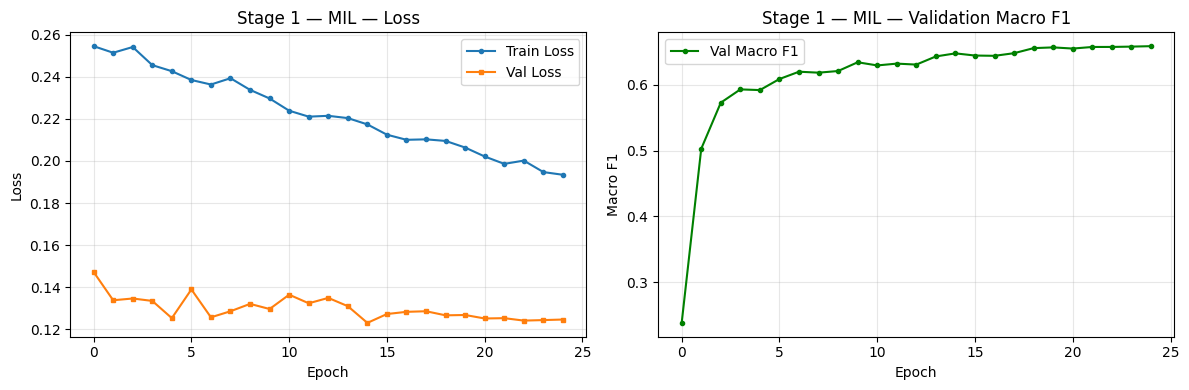


────────────────────────────────────────────────────────────
Running post-training calibration & threshold optimization...

  POST-TRAINING CALIBRATION & THRESHOLD OPTIMIZATION
  interjection          temp=1.45  thresh=0.41  pos_prob=0.561  neg_prob=0.239  sep=0.322
  prolongation          temp=1.26  thresh=0.51  pos_prob=0.592  neg_prob=0.348  sep=0.245
  word_repetition       temp=1.97  thresh=0.52  pos_prob=0.610  neg_prob=0.359  sep=0.251

  Val F1 (raw, fixed 0.5):         0.6591
  Val F1 (calibrated, fixed 0.5):   0.6591
  Val F1 (calibrated, optimised):   0.6650
[2026-03-18 17:18:39] [INFO] Stage 1 complete. Best val_macro_F1=0.6591


In [6]:
from torch.utils.data import DataLoader, WeightedRandomSampler
from src.data.dataset import StutterDatasetClipLevel
from src.training.stage1_mil import train_stage1, calibrate_and_optimize
from src.evaluation.visualization import plot_training_curves
# from src.config import Config

# ── Quick-test override: set to True to reduce epochs for fast iteration ──
# Set to False for full training (recommended for final results)
QUICK_TEST = True
if QUICK_TEST:
    config.NUM_EPOCHS_STAGE1 = 25
    config.NUM_EPOCHS_STAGE2 = 20

# Device selection
if torch.backends.mps.is_available() and torch.backends.mps.is_built():
    config.DEVICE = torch.device("mps")
    print("✓ Apple MPS GPU detected")
elif torch.cuda.is_available():
    config.DEVICE = torch.device("cuda")
else:
    config.DEVICE = torch.device("cpu")

logger.log(f"Environment ready. Device={config.DEVICE}")

# IMPORTANT
model = model.to(config.DEVICE)

# Datasets — training set uses augmentation for better generalisation
train_dataset = StutterDatasetClipLevel(
    os.path.join(config.DATA_PROCESSED, 'train_split.csv'),
    preprocessor, label2idx,
    augment=getattr(config, 'USE_AUGMENTATION', True),
)
val_dataset = StutterDatasetClipLevel(
    os.path.join(config.DATA_PROCESSED, 'val_split.csv'),
    preprocessor, label2idx,
)
test_dataset = StutterDatasetClipLevel(
    os.path.join(config.DATA_PROCESSED, 'test_split.csv'),
    preprocessor, label2idx,
)

print(f"Train: {len(train_dataset)}  Val: {len(val_dataset)}  Test: {len(test_dataset)}")

# Print per-class distribution (including negatives)
for split_name, ds in [("Train", train_dataset), ("Val", val_dataset), ("Test", test_dataset)]:
    counts = ds.df['class'].value_counts()
    print(f"\n  {split_name} distribution:")
    for cls in config.STUTTER_TYPES:
        cnt = counts.get(cls, 0)
        print(f"    {cls:20s}: {cnt:5d}  ({cnt/len(ds)*100:.1f}%)")
    neg_cnt = counts.get('__negative__', 0)
    if neg_cnt > 0:
        print(f"    {'__negative__':20s}: {neg_cnt:5d}  ({neg_cnt/len(ds)*100:.1f}%)")

# Warn if any stutter class is missing
for split_name, ds in [("Train", train_dataset), ("Val", val_dataset)]:
    found = set(ds.df['class'].unique()) - {'__negative__'}
    missing = set(config.STUTTER_TYPES) - found
    if missing:
        print(f"\n  ⚠️  {split_name} is missing classes: {missing}")

# Class-balanced sampling — oversamples minority classes each epoch
if getattr(config, 'USE_BALANCED_SAMPLING', True):
    sample_weights = train_dataset.get_sample_weights().cpu()
    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(train_dataset),
        replacement=True,
    )
    train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE,
                              sampler=sampler, num_workers=0, drop_last=True)
    print("\n✓ Using class-balanced WeightedRandomSampler")
else:
    train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE,
                              shuffle=True, num_workers=0, drop_last=True)

val_loader   = DataLoader(val_dataset, batch_size=config.BATCH_SIZE,
                          shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset, batch_size=config.BATCH_SIZE,
                          shuffle=False, num_workers=0)

# Train Stage 1
model, stage1_history = train_stage1(
    model, train_loader, val_loader, config,
)

# Save checkpoint
s1_path = os.path.join(config.CHECKPOINT_DIR, 'stage1_best.pth')
torch.save({'model_state_dict': model.state_dict(),
            'history': stage1_history}, s1_path)
print(f"\nStage 1 model saved: {s1_path}")
print(f"Best macro F1: {max(stage1_history['val_accuracy']):.4f}")

plot_training_curves(
    stage1_history, title='Stage 1 — MIL',
    save_path=os.path.join(config.OUTPUT_DIR, 'visualizations', 'stage1_curves.png'),
)

# ── Post-training calibration (runs on validation set) ──
print("\n" + "─"*60)
print("Running post-training calibration & threshold optimization...")
calibration_info = calibrate_and_optimize(model, val_loader, config)

logger.log(f"Stage 1 complete. Best val_macro_F1={max(stage1_history['val_accuracy']):.4f}")

---
## Phase 7 — Pseudo-Label Generation

In [7]:
from src.training.pseudo_labels import generate_pseudo_labels, save_pseudo_labels

train_df = pd.read_csv(os.path.join(config.DATA_PROCESSED, 'train_split.csv'))

pseudo_labels = generate_pseudo_labels(
    model, train_df, preprocessor, config,
)

pseudo_path = os.path.join(config.DATA_PROCESSED, 'pseudo_labels.npz')
save_pseudo_labels(pseudo_labels, pseudo_path)

logger.log(f"Pseudo-labels generated for {len(pseudo_labels)} samples")

Pseudo-labels Pass 1: running inference and collecting statistics...


Pass 1:   0%|          | 0/6676 [00:00<?, ?it/s]

Per-class adaptive thresholds:
  interjection        : 0.583
  prolongation        : 0.442
  word_repetition     : 0.562
Pass 2: generating pseudo-labels from cached probabilities...


Pass 2:   0%|          | 0/6676 [00:00<?, ?it/s]


Pseudo-labels: 6676 samples, 4697 with events (70.4%)
Per-class coverage:
  interjection        : 1842 samples with events
  prolongation        : 1754 samples with events
  word_repetition     : 1326 samples with events
Pseudo-labels saved → /Users/kavindumihiranga/Documents/Code_Base 3/data/processed/pseudo_labels.npz
[2026-03-18 17:26:17] [INFO] Pseudo-labels generated for 6676 samples


---
## Phase 8 — Stage 2: Self-Training with Mean Teacher

Loaded pseudo-labels for 6676 samples
Class weights (cap=15.0): {0: 0.77, 1: 1.09, 2: 1.27}
  Stage 2 encoder LR: 2.5e-06

STAGE 2 — SELF-TRAINING WITH MEAN TEACHER  (20 epochs)
  Lambda consistency: 0.5
  Lambda weak: 0.5
  EMA decay: 0.999


S2 Ep 1:   0%|          | 0/417 [00:00<?, ?it/s]

Ep  1/20  loss=0.3955  val_F1=0.6381  ★


S2 Ep 2:   0%|          | 0/417 [00:00<?, ?it/s]

Ep  2/20  loss=0.4003  val_F1=0.6488  ★


...

Ep 18/20  loss=0.3285  val_F1=0.6648


S2 Ep 19:   0%|          | 0/417 [00:00<?, ?it/s]

Ep 19/20  loss=0.3295  val_F1=0.6657


S2 Ep 20:   0%|          | 0/417 [00:00<?, ?it/s]

Ep 20/20  loss=0.3308  val_F1=0.6657
Loaded best student (val_F1=0.6705)
Stage 2 model saved: /Users/kavindumihiranga/Documents/Code_Base 3/models/checkpoints/stage2_final.pth
  (includes calibration parameters for deployment)


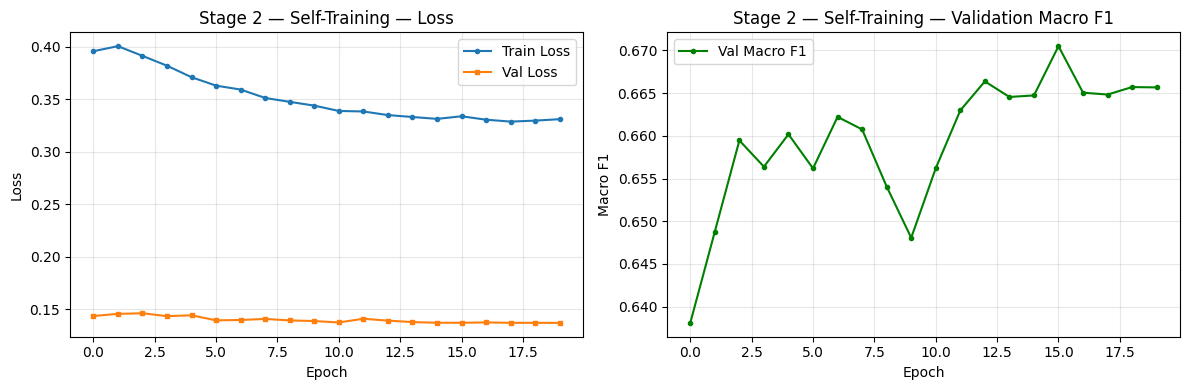

[2026-03-19 00:19:15] [INFO] Stage 2 complete.


In [8]:
from src.data.dataset import StutterDatasetFrameLevel
from src.training.stage2_self_training import MeanTeacher, train_stage2

# Frame-level datasets (augment clip datasets with pseudo-labels)
train_dataset_s2 = StutterDatasetFrameLevel(
    train_dataset, pseudo_labels_path=pseudo_path,
)
val_dataset_s2 = StutterDatasetFrameLevel(val_dataset)

train_loader_s2 = DataLoader(train_dataset_s2, batch_size=config.BATCH_SIZE,
                             shuffle=True, num_workers=0, drop_last=True)
val_loader_s2   = DataLoader(val_dataset_s2, batch_size=config.BATCH_SIZE,
                             shuffle=False, num_workers=0)

# Initialise Mean Teacher (student = current model)
mean_teacher = MeanTeacher(model, ema_decay=config.EMA_DECAY)

# Pass calibration_info so Stage 2 validation uses calibrated thresholds
mean_teacher, stage2_history = train_stage2(
    mean_teacher, train_loader_s2, val_loader_s2, config,
    calibration_info=calibration_info,
)

best_model = mean_teacher.student

# Save final model (include calibration info for deployment)
s2_path = os.path.join(config.CHECKPOINT_DIR, 'stage2_final.pth')
torch.save({
    'student_state_dict': best_model.state_dict(),
    'teacher_state_dict': mean_teacher.teacher.state_dict(),
    'history': stage2_history,
    'calibration': {
        'temperatures': calibration_info['temperatures'],
        'thresholds': calibration_info['thresholds'],
    },
}, s2_path)
print(f"Stage 2 model saved: {s2_path}")
print(f"  (includes calibration parameters for deployment)")

plot_training_curves(
    stage2_history, title='Stage 2 — Self-Training',
    save_path=os.path.join(config.OUTPUT_DIR, 'visualizations', 'stage2_curves.png'),
)

logger.log("Stage 2 complete.")

---
## Phase 9 — Probability Calibration, Evaluation & Metrics

> **Key improvements in this phase:**
> 1. **Probability Calibration** — per-class temperature scaling (Platt scaling) fixes poorly-calibrated sigmoid outputs where true positives cluster at low probabilities.
> 2. **Adaptive Per-Class Thresholds** — instead of fixed 0.5, thresholds are optimised on the validation set and transferred to the test set (no leakage).
> 3. **Proper Multi-Label Metrics** — Hamming loss, subset accuracy, sample-averaged F1 replace misleading accuracy.
> 4. **Calibration Diagnostics** — reliability diagrams show how well predicted probabilities match true frequencies.

  PROBABILITY CALIBRATION (Platt Scaling)

Class                 Temperature  Pos μ(raw)  Neg μ(raw)  Separation
----------------------------------------------------------------------
  interjection              1.580      0.5301      0.1619      0.3682
  prolongation              2.951      0.5775      0.2527      0.3248
  word_repetition           3.093      0.5463      0.2513      0.2950

  PER-CLASS THRESHOLD OPTIMIZATION (on calibrated val set)

Class                 Thresh(raw)   F1(raw)  Thresh(cal)   F1(cal)
--------------------------------------------------------------------
  interjection               0.46    0.7469         0.44    0.7458
  prolongation               0.43    0.6690         0.48    0.6690
  word_repetition            0.51    0.6342         0.51    0.6307

  TEST SET — (A) RAW PROBS, FIXED THRESHOLD 0.5
  Hamming Accuracy : 0.8094
  Subset Accuracy  : 0.5432
  Hamming Loss     : 0.1906
  Sample F1        : 0.4468
  Macro Precision  : 0.6569
  Macro Recall     

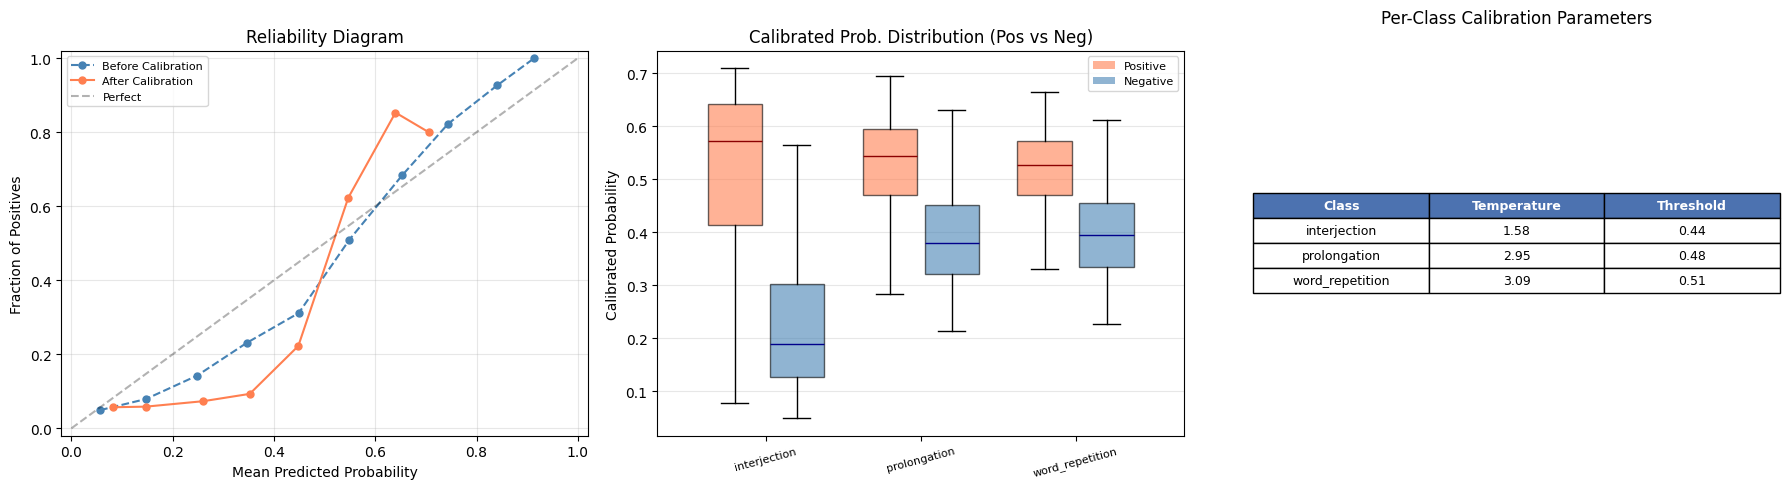

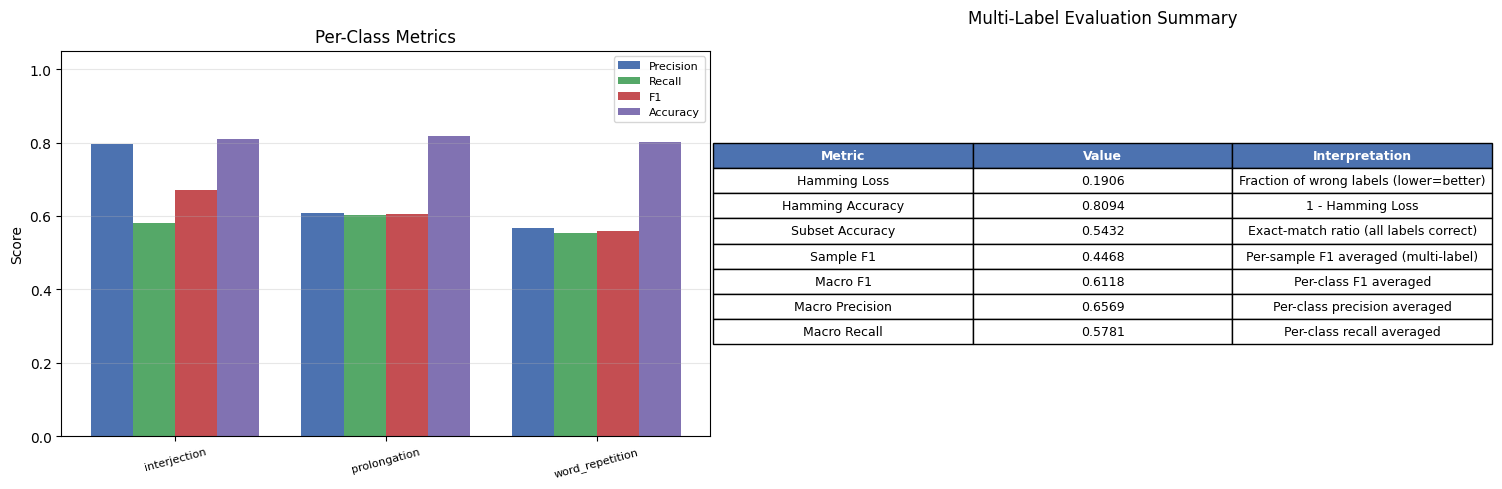

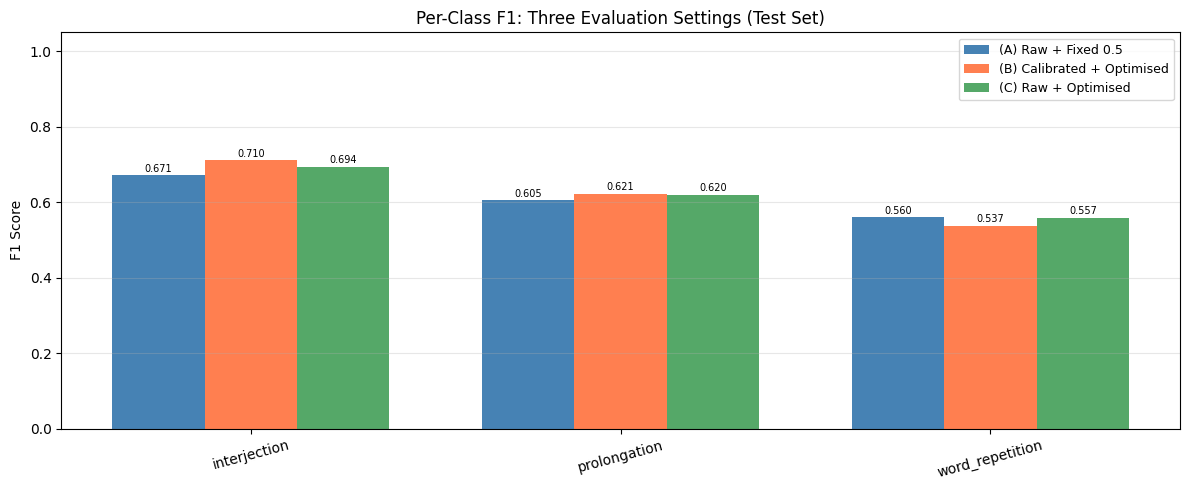


=== Event-Level Metrics (with post-processing) ===
  Event F1 (IoU>=0.3): 0.5488 +/- 0.4580
  Onset RMSE  : 50.5 ms
  Offset RMSE : 40.1 ms
[2026-03-19 01:32:50] [INFO] Evaluation done. Clip F1(raw)=0.6118  Clip F1(cal+opt)=0.6229  Hamming=0.1906


In [9]:
from src.evaluation.metrics import (
    detect_events, event_level_f1, boundary_rmse,
    clip_level_metrics, gate_feature_correlation,
    optimize_per_class_thresholds, apply_per_class_thresholds,
    calibrate_probabilities, apply_calibration,
)
from src.evaluation.visualization import (
    plot_calibration_analysis, plot_multilabel_summary,
)

# ── Helper: extract clip-level probabilities using SAME pooling as training ──
def _get_clip_probs(model, loader, config):
    """Extract clip-level probabilities matching the MIL pooling used in training."""
    model.eval()
    all_preds, all_targets = [], []
    pooling = getattr(config, 'MIL_POOLING', 'mixed')
    mixed_alpha = getattr(config, 'MIL_MIXED_ALPHA', 0.7)

    with torch.no_grad():
        for batch in loader:
            audio = batch['audio'].to(config.DEVICE)
            targets = batch['clip_label']
            logits = model(audio)  # (B, T, C)

            if pooling == "mixed":
                max_logits, _ = torch.max(logits, dim=1)
                mean_logits = torch.mean(logits, dim=1)
                clip_logits = mixed_alpha * max_logits + (1 - mixed_alpha) * mean_logits
            elif pooling == "mean":
                clip_logits = torch.mean(logits, dim=1)
            else:
                clip_logits, _ = torch.max(logits, dim=1)

            probs = torch.sigmoid(clip_logits).cpu().numpy()
            all_preds.append(probs)
            all_targets.append(targets.numpy())

    return np.concatenate(all_preds), np.concatenate(all_targets)

# ════════════════════════════════════════════════════════════════════════
# STEP 1: Collect validation predictions for calibration
# ════════════════════════════════════════════════════════════════════════
best_model.eval()
val_preds, val_targets = _get_clip_probs(best_model, val_loader, config)

# ════════════════════════════════════════════════════════════════════════
# STEP 2: Probability calibration (per-class temperature scaling)
# ════════════════════════════════════════════════════════════════════════
print("="*60)
print("  PROBABILITY CALIBRATION (Platt Scaling)")
print("="*60)

cal_result = calibrate_probabilities(val_preds, val_targets, classes)
temperatures = cal_result['temperatures']
val_preds_cal = apply_calibration(val_preds, temperatures, classes)

print(f"\n{'Class':20s}  {'Temperature':>11s}  {'Pos μ(raw)':>10s}  {'Neg μ(raw)':>10s}  {'Separation':>10s}")
print("-" * 70)
for cls in classes:
    diag = cal_result['diagnostics'][cls]
    print(f"  {cls:18s}  {temperatures[cls]:11.3f}  "
          f"{diag['mean_pos_prob']:10.4f}  "
          f"{diag['mean_neg_prob']:10.4f}  "
          f"{diag.get('separation', 0):10.4f}")

# ════════════════════════════════════════════════════════════════════════
# STEP 3: Per-class threshold optimization on CALIBRATED validation preds
# ════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("  PER-CLASS THRESHOLD OPTIMIZATION (on calibrated val set)")
print("="*60)

opt_result = optimize_per_class_thresholds(val_preds_cal, val_targets, classes)
val_thresholds = opt_result['thresholds']

# Also get thresholds on raw (uncalibrated) for comparison
opt_result_raw = optimize_per_class_thresholds(val_preds, val_targets, classes)

print(f"\n{'Class':20s}  {'Thresh(raw)':>11s}  {'F1(raw)':>8s}  {'Thresh(cal)':>11s}  {'F1(cal)':>8s}")
print("-" * 68)
for cls in classes:
    print(f"  {cls:18s}  {opt_result_raw['thresholds'][cls]:11.2f}  "
          f"{opt_result_raw['per_class_f1'][cls]:8.4f}  "
          f"{val_thresholds[cls]:11.2f}  "
          f"{opt_result['per_class_f1'][cls]:8.4f}")

# Store calibration info for downstream use
calibration_info = {
    'temperatures': temperatures,
    'thresholds': val_thresholds,
    'val_preds': val_preds,
    'val_preds_cal': val_preds_cal,
    'val_targets': val_targets,
    'diagnostics': cal_result['diagnostics'],
}

# ════════════════════════════════════════════════════════════════════════
# STEP 4: Evaluate on held-out test set (THREE settings)
# ════════════════════════════════════════════════════════════════════════
all_preds, all_targets = _get_clip_probs(best_model, test_loader, config)
all_preds_cal = apply_calibration(all_preds, temperatures, classes)

# Setting A: Fixed 0.5 on raw probabilities (baseline)
clip_metrics = clip_level_metrics(all_preds, all_targets, classes)
print("\n" + "="*60)
print("  TEST SET — (A) RAW PROBS, FIXED THRESHOLD 0.5")
print("="*60)
print(f"  Hamming Accuracy : {clip_metrics['accuracy']:.4f}")
print(f"  Subset Accuracy  : {clip_metrics['subset_accuracy']:.4f}")
print(f"  Hamming Loss     : {clip_metrics['hamming_loss']:.4f}")
print(f"  Sample F1        : {clip_metrics['sample_f1']:.4f}")
print(f"  Macro Precision  : {clip_metrics['precision']:.4f}")
print(f"  Macro Recall     : {clip_metrics['recall']:.4f}")
print(f"  Macro F1         : {clip_metrics['f1']:.4f}")

# Setting B: Calibrated probs, optimised per-class thresholds (best)
clip_metrics_cal = clip_level_metrics(all_preds_cal, all_targets, classes, threshold=0.5)
opt_test = apply_per_class_thresholds(all_preds_cal, all_targets, classes, val_thresholds)
print("\n" + "="*60)
print("  TEST SET — (B) CALIBRATED PROBS, VAL-OPTIMISED THRESHOLDS (recommended)")
print("="*60)
print(f"\n{opt_test['overall']['report']}")

# Setting C: Raw probs, val-optimised thresholds (for comparison)
opt_test_raw = apply_per_class_thresholds(all_preds, all_targets, classes,
                                           opt_result_raw['thresholds'])

# ════════════════════════════════════════════════════════════════════════
# STEP 5: Class-Wise Accuracy Dashboard (all 3 settings)
# ════════════════════════════════════════════════════════════════════════
print("="*60)
print("  CLASS-WISE ACCURACY DASHBOARD")
print("="*60)
print(f"\n{'Class':20s}  {'Support':>7s}  {'Prec':>6s}  {'Recall':>6s}  "
      f"{'F1(A)':>6s}  {'F1(B)':>6s}  {'F1(C)':>6s}  {'ClsAcc':>6s}  {'Thresh':>6s}")
print("-" * 90)
for cls in classes:
    pc = clip_metrics['per_class'][cls]
    f1_a = pc['f1']
    f1_b = opt_test['per_class_f1'][cls]
    f1_c = opt_test_raw['per_class_f1'][cls]
    cls_acc = pc['accuracy']
    thresh = val_thresholds[cls]
    print(f"  {cls:18s}  {pc['support']:7d}  {pc['precision']:6.3f}  {pc['recall']:6.3f}  "
          f"{f1_a:6.3f}  {f1_b:6.3f}  {f1_c:6.3f}  {cls_acc:6.3f}  {thresh:6.2f}")

print(f"\n  {'MACRO AVG':18s}  {'':7s}  {clip_metrics['precision']:6.3f}  "
      f"{clip_metrics['recall']:6.3f}  {clip_metrics['f1']:6.3f}  "
      f"{opt_test['overall']['f1']:6.3f}  {opt_test_raw['overall']['f1']:6.3f}")
print(f"\n  Legend: A=raw+fixed0.5  B=calibrated+optimised  C=raw+optimised")

# ════════════════════════════════════════════════════════════════════════
# STEP 6: Calibration diagnostics visualisation
# ════════════════════════════════════════════════════════════════════════
plot_calibration_analysis(
    val_preds, val_preds_cal, val_targets, classes,
    temperatures, val_thresholds,
    save_path=os.path.join(config.OUTPUT_DIR, 'visualizations', 'calibration_analysis.png'),
)

# ════════════════════════════════════════════════════════════════════════
# STEP 7: Multi-label metrics dashboard
# ════════════════════════════════════════════════════════════════════════
# Use calibrated probs with optimised thresholds for the main report
cal_clip_metrics = clip_level_metrics(all_preds_cal, all_targets, classes, threshold=0.5)
plot_multilabel_summary(
    cal_clip_metrics, classes,
    save_path=os.path.join(config.OUTPUT_DIR, 'visualizations', 'multilabel_summary.png'),
)

# ════════════════════════════════════════════════════════════════════════
# STEP 8: Per-class F1 comparison (3 settings)
# ════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(classes))
width = 0.25
f1_a = [clip_metrics['per_class'][c]['f1'] for c in classes]
f1_b = [opt_test['per_class_f1'][c] for c in classes]
f1_c = [opt_test_raw['per_class_f1'][c] for c in classes]
bars1 = ax.bar(x - width, f1_a, width, label='(A) Raw + Fixed 0.5', color='steelblue')
bars2 = ax.bar(x, f1_b, width, label='(B) Calibrated + Optimised', color='coral')
bars3 = ax.bar(x + width, f1_c, width, label='(C) Raw + Optimised', color='#55A868')
ax.set_ylabel('F1 Score')
ax.set_title('Per-Class F1: Three Evaluation Settings (Test Set)')
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=15)
ax.legend(fontsize=9)
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)
for bars in [bars1, bars2, bars3]:
    for b in bars:
        if b.get_height() > 0.01:
            ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
                    f'{b.get_height():.3f}', ha='center', fontsize=7)
plt.tight_layout()
plt.savefig(os.path.join(config.OUTPUT_DIR, 'visualizations', 'per_class_f1.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# ════════════════════════════════════════════════════════════════════════
# STEP 9: Event-level metrics on pseudo-labelled subset
# ════════════════════════════════════════════════════════════════════════
print("\n=== Event-Level Metrics (with post-processing) ===")
event_f1_scores, onset_rmses, offset_rmses = [], [], []
medfilt = getattr(config, 'EVENT_MEDIAN_FILTER_SIZE', 5)
merge_gap = getattr(config, 'EVENT_MERGE_GAP', 2)

with torch.no_grad():
    for i in range(min(200, len(train_dataset_s2))):
        sample = train_dataset_s2[i]
        if not sample['has_pseudo_label']:
            continue
        audio = sample['audio'].unsqueeze(0).to(config.DEVICE)
        ft = sample['frame_label'].numpy()
        logits = best_model(audio)
        preds = (torch.sigmoid(logits).squeeze(0).cpu().numpy() > 0.5).astype(float)

        min_t = min(preds.shape[0], ft.shape[0])
        pred_ev = detect_events(preds[:min_t], min_event_length=3,
                                median_filter_size=medfilt, merge_gap=merge_gap)
        gt_ev   = detect_events(ft[:min_t], min_event_length=3)

        if gt_ev:
            ef1 = event_level_f1(pred_ev, gt_ev, iou_threshold=0.3)
            event_f1_scores.append(ef1['f1'])
            br = boundary_rmse(pred_ev, gt_ev, ms_per_frame=20.0)
            if not np.isnan(br['onset_rmse_ms']):
                onset_rmses.append(br['onset_rmse_ms'])
                offset_rmses.append(br['offset_rmse_ms'])

if event_f1_scores:
    print(f"  Event F1 (IoU>=0.3): {np.mean(event_f1_scores):.4f} +/- {np.std(event_f1_scores):.4f}")
if onset_rmses:
    print(f"  Onset RMSE  : {np.mean(onset_rmses):.1f} ms")
    print(f"  Offset RMSE : {np.mean(offset_rmses):.1f} ms")

logger.log(f"Evaluation done. "
           f"Clip F1(raw)={clip_metrics['f1']:.4f}  "
           f"Clip F1(cal+opt)={opt_test['overall']['f1']:.4f}  "
           f"Hamming={clip_metrics['hamming_loss']:.4f}")

---
## Phase 10 — Interpretability Analysis (RQ2)

Rule contributions (stratified, 48 samples):
  interjection        : neural=0.564  burst=0.130  voicing=0.229  rhythm=0.077
  prolongation        : neural=0.568  burst=0.128  voicing=0.224  rhythm=0.080
  word_repetition     : neural=0.575  burst=0.127  voicing=0.223  rhythm=0.075
  Overall most important rule: voicing


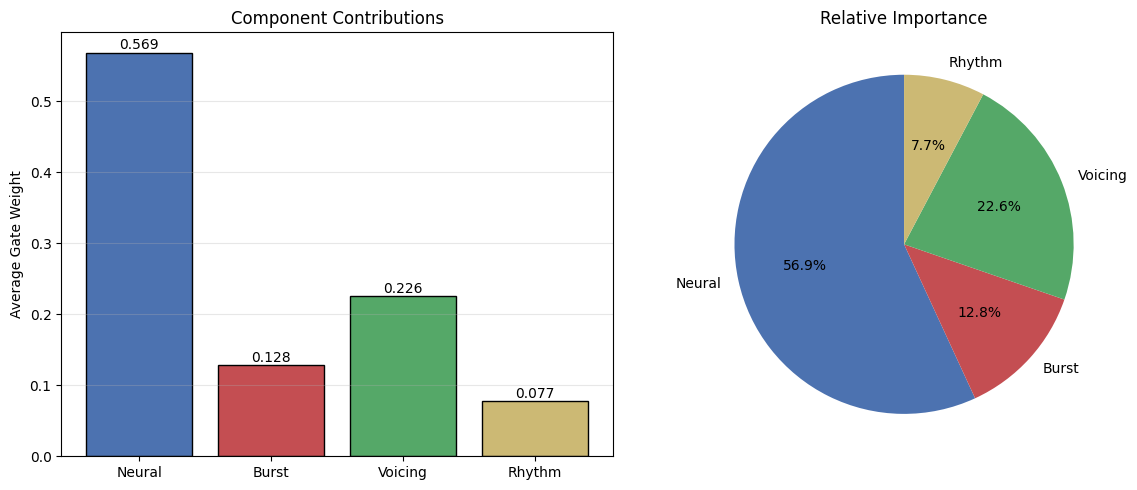


=== Gate-Feature Correlation (Pearson r) ===
  burst       : r = -0.0490
  voicing     : r = 0.1340
  rhythm      : r = 0.0727

=== Per-Class Rule Contributions ===

Class                     neural       burst     voicing      rhythm
--------------------------------------------------------------------
  interjection             0.564       0.130       0.229       0.077
  prolongation             0.568       0.128       0.224       0.080
  word_repetition          0.575       0.127       0.223       0.075
Visualising sample 0 (class: interjection)


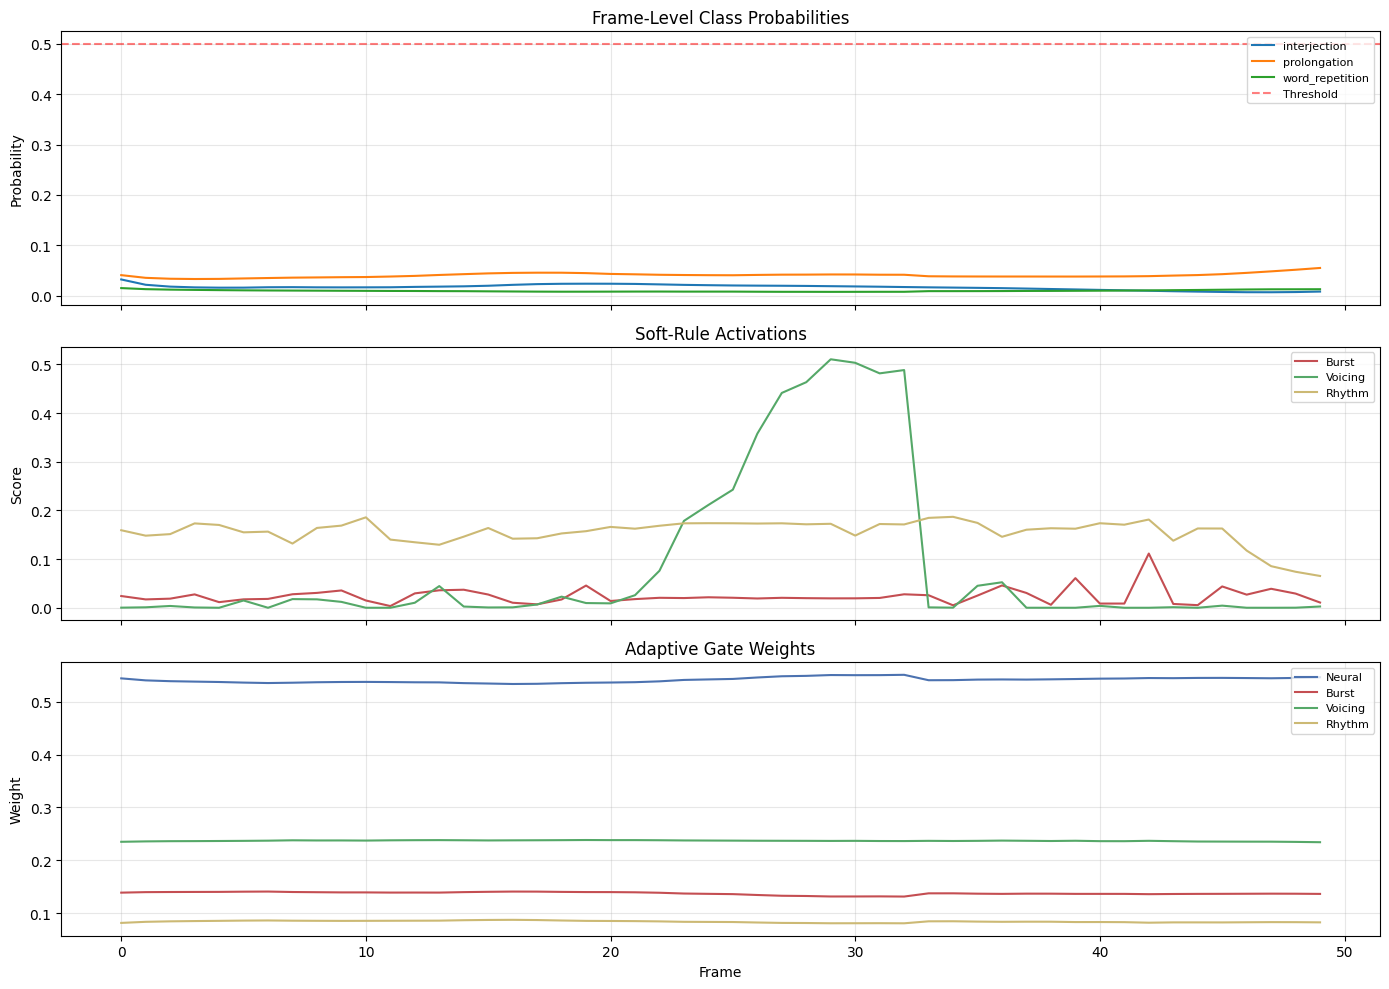

[2026-03-19 05:13:40] [INFO] Interpretability analysis complete.


In [18]:
from src.evaluation.interpretability import analyze_rule_contributions
from src.evaluation.visualization import plot_rule_contributions, plot_frame_predictions

# Rule contribution analysis
contrib = analyze_rule_contributions(best_model, train_dataset_s2, config, num_samples=50)

plot_rule_contributions(
    contrib['overall'],
    save_path=os.path.join(config.OUTPUT_DIR, 'visualizations', 'rule_contributions.png'),
)

# Gate-feature Pearson's r (explanation fidelity)
print("\n=== Gate-Feature Correlation (Pearson r) ===")
all_gates, all_rules = [], []
with torch.no_grad():
    for i in range(min(100, len(train_dataset_s2))):
        sample = train_dataset_s2[i]
        audio = sample['audio'].unsqueeze(0).to(config.DEVICE)
        _, det = best_model(audio, return_details=True)
        all_gates.append(det['gate_weights'].squeeze(0).cpu().numpy())
        all_rules.append(det['rule_scores'].squeeze(0).cpu().numpy())

all_gates_flat = np.concatenate(all_gates, axis=0)
all_rules_flat = np.concatenate(all_rules, axis=0)
corr = gate_feature_correlation(all_gates_flat, all_rules_flat)
for rname, rval in corr.items():
    print(f"  {rname:12s}: r = {rval:.4f}")

# Per-class rule contribution heatmap
print("\n=== Per-Class Rule Contributions ===")
display_names = ["neural", "burst", "voicing", "rhythm"]
print(f"\n{'Class':20s}", end="")
for rn in display_names:
    print(f"  {rn:>10s}", end="")
print()
print("-" * (20 + 12 * len(display_names)))
for cls, vals in contrib['per_class'].items():
    print(f"  {cls:18s}", end="")
    for rn in display_names:
        v = vals.get(rn, 0.0)
        print(f"  {v:10.3f}", end="")
    print()

# Visualise one sample's frame-level predictions
# Find a sample that HAS pseudo-label events (non-empty ground truth)
viz_sample = None
for _vi in range(len(train_dataset_s2)):
    _vs = train_dataset_s2[_vi]
    if _vs['has_pseudo_label'] and _vs['frame_label'].sum() > 0 and _vs['class_name'] != '__negative__':
        viz_sample = _vs
        print(f"Visualising sample {_vi} (class: {_vs['class_name']})")
        break
if viz_sample is None:
    print("Warning: no sample with pseudo-label events found, using first sample")
    viz_sample = train_dataset_s2[0]

audio = viz_sample['audio'].unsqueeze(0).to(config.DEVICE)
with torch.no_grad():
    logits, det = best_model(audio, return_details=True)
n_frames = min(50, logits.shape[1])
fp = torch.sigmoid(logits).squeeze(0).cpu().numpy()[:n_frames]
rs = det['rule_scores'].squeeze(0).cpu().numpy()[:n_frames]
gw = det['gate_weights'].squeeze(0).cpu().numpy()[:n_frames]

plot_frame_predictions(
    fp, rs, gw, classes,
    save_path=os.path.join(config.OUTPUT_DIR, 'visualizations', 'frame_predictions.png'),
)

logger.log("Interpretability analysis complete.")

---
## Phase 11 — Ablation Tests (RQ3)

Ablation test (142 samples):
  Full model F1:   0.5549
  No-rules F1:     0.5286
  Δ F1 (rules):    +0.0263
    interjection        : full=0.5549  no_rules=0.5286  Δ=+0.0263  (n=142)


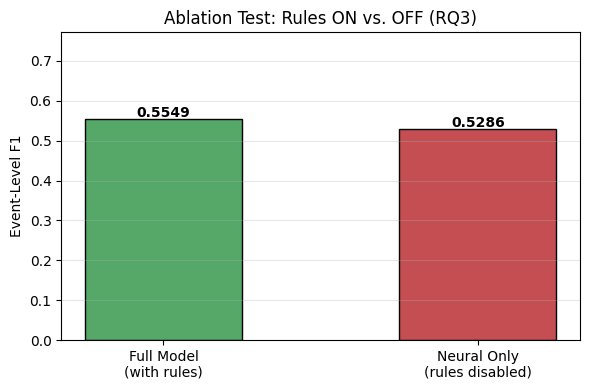

[2026-03-19 01:36:07] [INFO] Ablation: full=0.5549  no_rules=0.5286  delta=+0.0263


In [11]:
from src.evaluation.interpretability import ablation_test
from src.evaluation.visualization import plot_ablation_comparison

# Use more samples (200) for statistical significance
ablation = ablation_test(best_model, train_dataset_s2, config, num_samples=200)

plot_ablation_comparison(
    ablation['full_model_f1'], ablation['no_rules_f1'],
    save_path=os.path.join(config.OUTPUT_DIR, 'visualizations', 'ablation.png'),
)

logger.log(f"Ablation: full={ablation['full_model_f1']:.4f}  "
           f"no_rules={ablation['no_rules_f1']:.4f}  "
           f"delta={ablation['delta_f1']:+.4f}")

---
## Phase 12 — Demo & Final Summary

In [12]:
from src.evaluation.interpretability import demo_single_audio

# Run a demo on one audio file (using calibrated probabilities & optimised thresholds)
sample_path = dataset_df.iloc[0]['file_path']
demo = demo_single_audio(
    best_model, sample_path, preprocessor, config, idx2label,
    calibration_info=calibration_info,
)

print(json.dumps(demo, indent=2))

# Save demo output
demo_dir = os.path.join(config.OUTPUT_DIR, 'demos')
os.makedirs(demo_dir, exist_ok=True)
with open(os.path.join(demo_dir, 'single_audio_demo.json'), 'w') as f:
    json.dump(demo, f, indent=2)
print(f"Demo saved to {demo_dir}")

{
  "audio_file": "HVSA_0_1.wav",
  "duration_seconds": 3.0,
  "total_events": 1,
  "calibrated": true,
  "thresholds": {
    "interjection": 0.44285714285714284,
    "prolongation": 0.4755102040816327,
    "word_repetition": 0.5081632653061224
  },
  "events": [
    {
      "type": "interjection",
      "onset_ms": 1993.3,
      "offset_ms": 2114.1,
      "duration_ms": 120.8
    }
  ],
  "clinical_metrics": {
    "events_per_minute": 20.0,
    "avg_event_duration_ms": 120.0,
    "total_events": 1,
    "distribution": {
      "0": 1
    }
  },
  "rule_analysis": {
    "neural_contribution": 0.5629281401634216,
    "burst": 0.13074623048305511,
    "voicing": 0.22908572852611542,
    "rhythm": 0.07723986357450485
  }
}
Demo saved to /Users/kavindumihiranga/Documents/Code_Base 3/outputs/demos


In [13]:
print("\n" + "="*70)
print("  PIPELINE COMPLETE — FINAL SUMMARY")
print("="*70)

print(f"\nDATASET")
print(f"  Source       : SEP-28k")
print(f"  Classes      : {classes}")
print(f"  Total files  : {len(dataset_df)}")
print(f"  Splits       : train={len(train_dataset)} / val={len(val_dataset)} / test={len(test_dataset)}")
print(f"  Negatives    : {getattr(config, 'INCLUDE_NEGATIVES', False)} "
      f"({getattr(config, 'NEGATIVE_RATIO', 0)*100:.0f}%)")
print(f"  Augmentation : {getattr(config, 'USE_AUGMENTATION', False)}")
print(f"  Balanced     : {getattr(config, 'USE_BALANCED_SAMPLING', False)}")

print(f"\nMODEL")
print(f"  Architecture : NeuroSymbolicStutterDetector")
print(f"  Encoder      : {config.WAV2VEC2_MODEL} (top {getattr(config, 'UNFREEZE_ENCODER_LAYERS', 0)} layers unfrozen)")
print(f"  Temporal     : BiLSTM (hidden={config.TEMPORAL_HIDDEN_DIM}, layers={config.TEMPORAL_NUM_LAYERS})")
print(f"  Rules        : {config.NUM_RULES} differentiable soft rules (temperature-scaled)")
print(f"  Gating       : Adaptive sigmoid gating (anti-collapse, min-floor)")
print(f"  MIL pooling  : {getattr(config, 'MIL_POOLING', 'max')}")
print(f"  Dropout      : {config.DROPOUT}")
print(f"  Label smooth : {getattr(config, 'LABEL_SMOOTHING', 0)}")
print(f"  Trainable    : {trainable:,} params")
print(f"  Device       : {config.DEVICE}")

print(f"\nTRAINING")
print(f"  Stage 0 : Rule pre-training ({config.STAGE0_SYNTHETIC_SAMPLES} synthetic, {config.STAGE0_NUM_EPOCHS} epochs)")
print(f"  Stage 1 : MIL — best macro F1 = {max(stage1_history['val_accuracy']):.4f}")
print(f"  Stage 2 : Self-training with Mean Teacher")

print(f"\nCALIBRATION")
print(f"  Method       : Per-class temperature scaling (Platt scaling)")
print(f"  Temperatures : {', '.join(f'{c}={temperatures[c]:.2f}' for c in classes)}")
print(f"  Thresholds   : {', '.join(f'{c}={val_thresholds[c]:.2f}' for c in classes)}")

print(f"\nEVALUATION (A) — Raw Probabilities, Fixed Threshold 0.5")
print(f"  Hamming Accuracy     : {clip_metrics['accuracy']:.4f}")
print(f"  Subset Accuracy      : {clip_metrics['subset_accuracy']:.4f}")
print(f"  Hamming Loss         : {clip_metrics['hamming_loss']:.4f}")
print(f"  Sample F1            : {clip_metrics['sample_f1']:.4f}")
print(f"  Macro Precision      : {clip_metrics['precision']:.4f}")
print(f"  Macro Recall         : {clip_metrics['recall']:.4f}")
print(f"  Macro F1             : {clip_metrics['f1']:.4f}")

print(f"\nEVALUATION (B) — Calibrated Probabilities, Val-Optimised Thresholds ★")
print(f"  Macro F1             : {opt_test['overall']['f1']:.4f}")
print(f"  Macro Precision      : {opt_test['overall']['precision']:.4f}")
print(f"  Macro Recall         : {opt_test['overall']['recall']:.4f}")

print(f"\nEVALUATION (C) — Raw Probabilities, Val-Optimised Thresholds")
print(f"  Macro F1             : {opt_test_raw['overall']['f1']:.4f}")

print(f"\nIMPROVEMENT FROM CALIBRATION + THRESHOLDING")
delta_f1 = opt_test['overall']['f1'] - clip_metrics['f1']
print(f"  Macro F1 gain (B vs A): {delta_f1:+.4f}")

print(f"\nPER-CLASS F1 (test set, all settings):")
print(f"  {'Class':20s}  {'(A) Fixed':>9s}  {'(B) Cal+Opt':>11s}  {'(C) Raw+Opt':>11s}  {'Δ(B-A)':>7s}")
print(f"  {'-'*65}")
for cls in classes:
    f1_a = clip_metrics['per_class'][cls]['f1']
    f1_b = opt_test['per_class_f1'].get(cls, 0.0)
    f1_c = opt_test_raw['per_class_f1'].get(cls, 0.0)
    delta = f1_b - f1_a
    print(f"  {cls:20s}  {f1_a:9.4f}  {f1_b:11.4f}  {f1_c:11.4f}  {delta:+7.4f}")

if event_f1_scores:
    print(f"\nEVENT-LEVEL")
    print(f"  Event-level F1       : {np.mean(event_f1_scores):.4f} (IoU>=0.3)")
if onset_rmses:
    print(f"  Onset RMSE           : {np.mean(onset_rmses):.1f} ms")
    print(f"  Offset RMSE          : {np.mean(offset_rmses):.1f} ms")

print(f"\nINTERPRETABILITY")
print(f"  Most important rule  : {contrib['most_important_rule']}")
print(f"  Ablation delta F1    : {ablation['delta_f1']:+.4f}")
print(f"  Gate-feature corr.   : {corr}")

print(f"\nSAVED ARTEFACTS")
print(f"  Stage 0 rules  : {rule_ckpt}")
print(f"  Stage 1 model  : {s1_path}")
print(f"  Stage 2 model  : {s2_path}")
print(f"  Pseudo-labels  : {pseudo_path}")

print("\n" + "="*70)
logger.log("Pipeline complete.")


  PIPELINE COMPLETE — FINAL SUMMARY

DATASET
  Source       : SEP-28k
  Classes      : ['interjection', 'prolongation', 'word_repetition']
  Total files  : 9398
  Splits       : train=6676 / val=1391 / test=1331
  Negatives    : True (25%)
  Augmentation : True
  Balanced     : True

MODEL
  Architecture : NeuroSymbolicStutterDetector
  Encoder      : facebook/wav2vec2-base-960h (top 2 layers unfrozen)
  Temporal     : BiLSTM (hidden=256, layers=2)
  Rules        : 3 differentiable soft rules (temperature-scaled)
  Gating       : Adaptive sigmoid gating (anti-collapse, min-floor)
  MIL pooling  : mixed
  Dropout      : 0.3
  Label smooth : 0.05
  Trainable    : 18,245,540 params
  Device       : mps

TRAINING
  Stage 0 : Rule pre-training (5000 synthetic, 20 epochs)
  Stage 1 : MIL — best macro F1 = 0.6591
  Stage 2 : Self-training with Mean Teacher

CALIBRATION
  Method       : Per-class temperature scaling (Platt scaling)
  Temperatures : interjection=1.58, prolongation=2.95, word_r